# Example 17: Stateful Models and TBPTT

Standard backpropagation through time (BPTT) requires storing intermediate
activations for every timestep in a sequence. For very long sequences this
quickly exhausts GPU memory. Truncated Backpropagation Through Time (TBPTT)
solves this by splitting long sequences into manageable sub-windows while
carrying the RNN hidden state across them, enabling training on arbitrarily
long sequences with bounded memory.

## Prerequisites

This example builds on concepts from Examples 00-04. Make sure you have
completed those first.

## Setup

In [1]:
import torch

from tsfast.tsdata.benchmark import create_dls_silverbox
from tsfast.training import RNNLearner, fun_rmse

## The Memory Problem

When training RNNs, backpropagation stores intermediate activations for every
timestep. A sequence of length 10,000 requires roughly 100x more memory than
a sequence of length 100. For very long sequences this exceeds GPU memory.

TBPTT solves this by:

1. **Splitting** the long sequence into sub-windows (e.g., 100 timesteps each)
2. **Running** the forward pass on one sub-window at a time
3. **Computing gradients** only within each sub-window (truncated)
4. **Carrying the hidden state** from the end of one sub-window to the start
   of the next

This means the model still "sees" the full sequence through its hidden state,
but memory usage is bounded by `sub_seq_len` rather than the full sequence
length.

## Standard Training (Baseline)

First, train normally with a moderately large window to establish a reference
point. The full 500-step sequence is backpropagated through in one pass.

In [2]:
dls_standard = create_dls_silverbox(bs=16, win_sz=500, stp_sz=10)

lrn_standard = RNNLearner(dls_standard, rnn_type='lstm', hidden_size=40, metrics=[fun_rmse])
lrn_standard.fit_flat_cos(n_epoch=10, lr=3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 648.10it/s, train=0.0130 | valid=0.0061 | fun_rmse=0.0109]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 647.60it/s, train=0.0130 | valid=0.0061 | fun_rmse=0.0109]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/10: 100%|██████████| 300/300 [00:00<00:00, 937.29it/s, train=0.0050 | valid=0.0037 | fun_rmse=0.0097]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 883.05it/s, train=0.0034 | valid=0.0030 | fun_rmse=0.0096]

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 882.02it/s, train=0.0034 | valid=0.0030 | fun_rmse=0.0096]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 913.69it/s, train=0.0028 | valid=0.0029 | fun_rmse=0.0096]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 912.73it/s, train=0.0028 | valid=0.0029 | fun_rmse=0.0096]

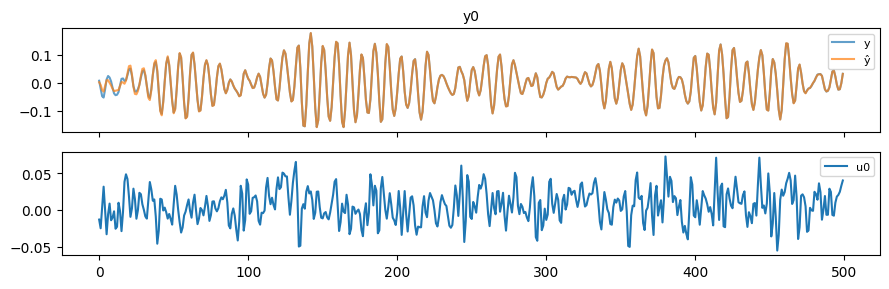

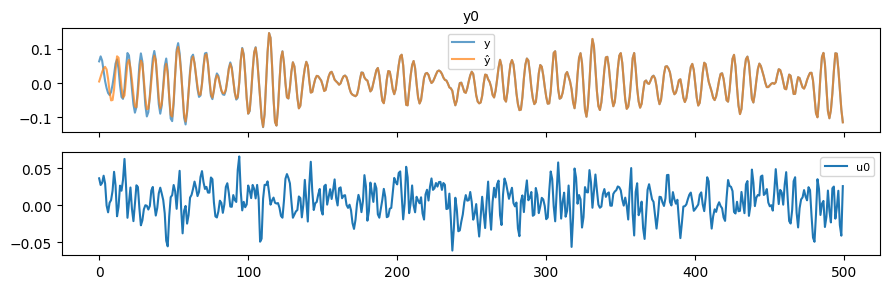

In [3]:
lrn_standard.show_results(max_n=2)

In [4]:
print(f"Standard: {lrn_standard.validate()}")

Standard: (0.002908384660258889, {'fun_rmse': 0.009578061290085316})


## TBPTT Training

The DataLoaders for TBPTT are identical to the baseline -- they yield full
500-step windows. The splitting into sub-windows happens inside the learner,
so `sub_seq_len` is a learner parameter, not a DataLoader parameter.

In [5]:
dls_tbptt = create_dls_silverbox(bs=16, win_sz=500, stp_sz=10)

## Stateful Model

Create a stateful RNN that maintains hidden state across sub-windows.

- **`sub_seq_len=100`** -- enables TBPTT: each 500-step window is split into
  5 sub-windows of 100 timesteps. The RNN does **not** reset its hidden
  state between sub-windows. Instead, the state from the previous sub-window
  initializes the next one, allowing information to flow across sub-window
  boundaries. The window size `win_sz` should ideally be divisible by
  `sub_seq_len`; if it is not, the final sub-window is simply shorter than
  the others (and with `cuda_graph=True` that ragged final chunk falls back
  to eager execution because its shape differs from the captured graph).

When `sub_seq_len` is set, `RNNLearner` automatically uses `TbpttLearner`
and a stateful RNN. The hidden state is carried across the sub-windows of
one window and reset between batches, so the state from one training sample
never bleeds into the next, unrelated sample.

In [6]:
lrn_tbptt = RNNLearner(
    dls_tbptt, rnn_type='lstm', hidden_size=40,
    sub_seq_len=100, metrics=[fun_rmse],
)

## Train with TBPTT

Training proceeds exactly like standard training. Under the hood, the
learner splits each batch into sub-windows, runs forward/backward on each
sub-window in turn, and carries the detached hidden state from one
sub-window to the next.

In [7]:
lrn_tbptt.fit_flat_cos(n_epoch=10, lr=3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  42%|████▏     | 127/300 [00:00<00:00, 252.33it/s]

Epoch 1/10:  87%|████████▋ | 261/300 [00:01<00:00, 260.66it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 260.66it/s, train=0.0084 | valid=0.0040 | fun_rmse=0.0097]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 257.43it/s, train=0.0084 | valid=0.0040 | fun_rmse=0.0097]

...

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10:  42%|████▏     | 127/300 [00:00<00:00, 252.35it/s]

Epoch 10/10:  85%|████████▍ | 254/300 [00:01<00:00, 251.85it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 251.85it/s, train=0.0030 | valid=0.0029 | fun_rmse=0.0095]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 253.12it/s, train=0.0030 | valid=0.0029 | fun_rmse=0.0095]

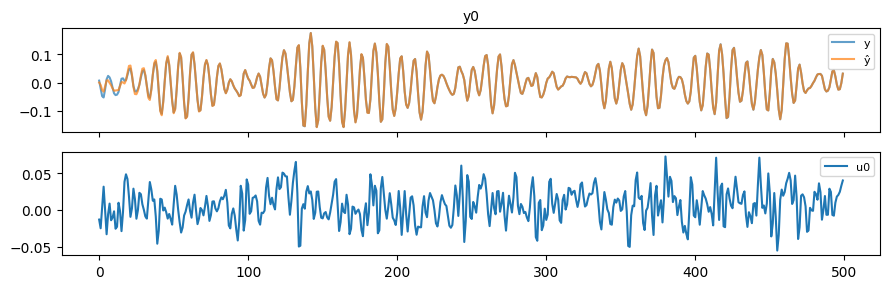

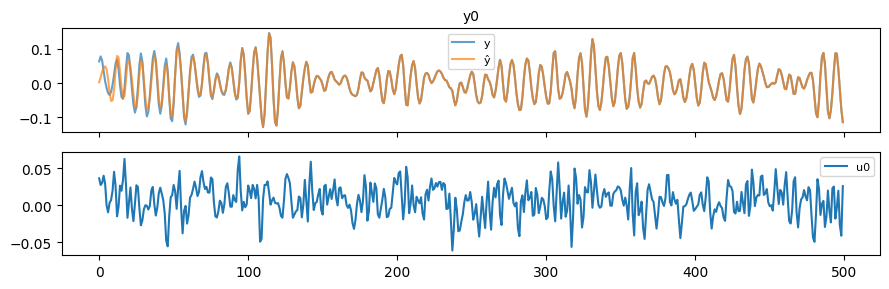

In [8]:
lrn_tbptt.show_results(max_n=2)

In [9]:
print(f"TBPTT: {lrn_tbptt.validate()}")

TBPTT: (0.002889072522521019, {'fun_rmse': 0.009543420746922493})


## Comparison

Compare the final validation metrics for both approaches.

In [10]:
print(f"Standard (full BPTT):  {lrn_standard.validate()}")
print(f"Stateful (TBPTT):      {lrn_tbptt.validate()}")

Standard (full BPTT):  (0.002908384660258889, {'fun_rmse': 0.009578061290085316})
Stateful (TBPTT):      (0.002889072522521019, {'fun_rmse': 0.009543420746922493})


TBPTT may have slightly different loss because gradients are truncated at
sub-window boundaries. However, performance should be comparable. The key
advantage is **memory efficiency** -- TBPTT can handle sequences that would
cause out-of-memory errors with standard training.

## Measuring the Memory Advantage

The 500-step windows above are short enough that both approaches fit
comfortably in GPU memory. The advantage becomes visible with much longer
windows. Here both variants train one short epoch on 5000-step windows
while `torch.cuda.max_memory_allocated()` tracks the peak: standard BPTT
stores activations for all 5000 timesteps of a batch, while TBPTT only ever
holds one 100-step sub-window at a time. The peak is reached on the first
batch, so a few batches (`n_batches_train=20`) suffice for the measurement.

In [11]:
if torch.cuda.is_available():
    def peak_train_memory_mb(sub_seq_len=None):
        dls_long = create_dls_silverbox(bs=16, win_sz=5000, stp_sz=1000, n_batches_train=20)
        kwargs = dict(rnn_type='lstm', hidden_size=40, metrics=[fun_rmse])
        if sub_seq_len is not None:
            kwargs['sub_seq_len'] = sub_seq_len
        lrn = RNNLearner(dls_long, **kwargs)
        torch.cuda.reset_peak_memory_stats()
        lrn.fit(1, lr=3e-3)
        return torch.cuda.max_memory_allocated() / 2**20

    mem_standard = peak_train_memory_mb()
    mem_tbptt = peak_train_memory_mb(sub_seq_len=100)
    print(f"Standard (full BPTT, win_sz=5000):    {mem_standard:7.1f} MiB")
    print(f"TBPTT (sub_seq_len=100, win_sz=5000): {mem_tbptt:7.1f} MiB")
    print(f"Memory ratio: {mem_standard / mem_tbptt:.1f}x")
else:
    print("CUDA not available -- skipping the GPU memory comparison.")

Epoch 1/1:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/1: 100%|██████████| 20/20 [00:00<00:00, 168.84it/s, train=0.0693 | valid=0.0440 | fun_rmse=0.0549]

Epoch 1/1: 100%|██████████| 20/20 [00:00<00:00, 168.34it/s, train=0.0693 | valid=0.0440 | fun_rmse=0.0549]

Epoch 1/1:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/1:  75%|███████▌  | 15/20 [00:00<00:00, 29.79it/s]

Epoch 1/1: 100%|██████████| 20/20 [00:00<00:00, 29.79it/s, train=0.0072 | valid=0.0036 | fun_rmse=0.0051]

Epoch 1/1: 100%|██████████| 20/20 [00:00<00:00, 29.70it/s, train=0.0072 | valid=0.0036 | fun_rmse=0.0051]

Standard (full BPTT, win_sz=5000):      381.8 MiB
TBPTT (sub_seq_len=100, win_sz=5000):    32.4 MiB
Memory ratio: 11.8x


## When to Use TBPTT

TBPTT is most useful when:

- **Sequences are very long** (thousands of timesteps or more) and
  full backpropagation would exhaust GPU memory.
- **GPU memory is limited** and you need to keep memory usage bounded.
- **The system has long-range dependencies** that benefit from a large
  `win_sz`, but you cannot afford to backpropagate through the entire window.

For short sequences (under ~1000 timesteps), standard training is simpler and
usually sufficient. The overhead of managing sub-windows and stateful hidden
state is not worth the complexity for sequences that already fit in memory.

## Key Takeaways

- **TBPTT splits long windows into sub-windows** inside the learner; the
  DataLoaders are the same as for standard training.
- **`sub_seq_len`** in `RNNLearner` enables TBPTT and makes the RNN carry its
  hidden state across sub-windows instead of resetting to zero each time.
- **Hidden state is reset between batches** so different training samples do
  not bleed into each other.
- **Gradients are truncated** to `sub_seq_len` timesteps, bounding memory
  usage regardless of the full sequence length.
- **Hidden state spans the full sequence**, preserving long-range information
  even though gradients are truncated.
- **Use TBPTT when sequences are too long** for standard backpropagation to
  fit in GPU memory.